In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# loading the data set
data = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Converting into Data frame
df = pd.DataFrame(data)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# CHECKING THE DATA STRUCTURE
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Data size
df.shape

(7043, 21)

In [10]:
# checking for misiing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
# Statistic Summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
# checking data types
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [14]:
# checking unique values
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [15]:
# No:of churned and non-churned customer
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


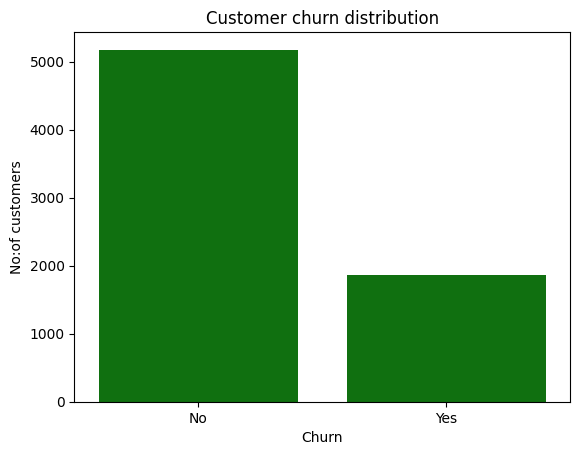

In [19]:
from matplotlib.typing import LineStyleType
# visulaizing churn
sns.countplot(x="Churn",data=df,color="green")
plt.title("Customer churn distribution")
plt.xlabel("Churn")
plt.ylabel("No:of customers")
plt.show()

In [20]:
# Churn percentage
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [22]:
# Business Question ---> does churn differ between male and female customers
pd.crosstab(df["gender"],df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


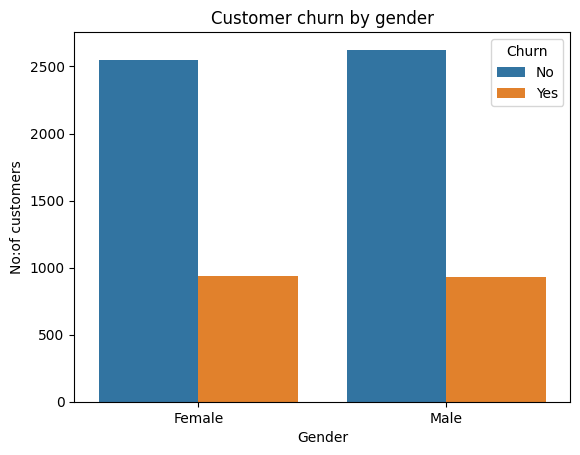

In [24]:
# visualize churn by gender
sns.countplot(x="gender",hue="Churn",data=df)
plt.title("Customer churn by gender")
plt.xlabel("Gender")
plt.ylabel("No:of customers")
plt.show()

In [25]:
# Churn by contract type
pd.crosstab(df['Contract'],df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


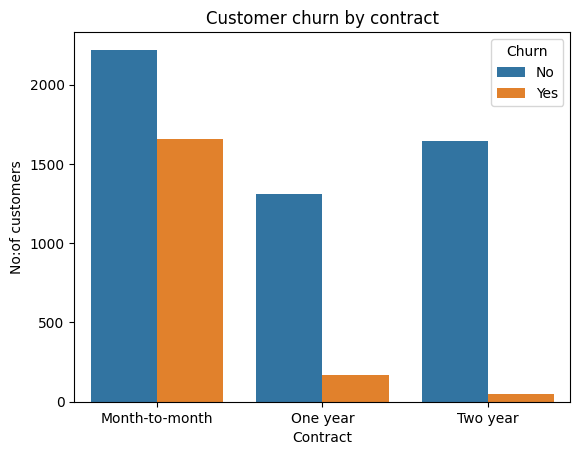

In [26]:
# visualize churn by contract
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Customer churn by contract")
plt.xlabel("Contract")
plt.ylabel("No:of customers")
plt.show()

In [27]:
# Churn by internet- service
pd.crosstab(df['InternetService'],df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


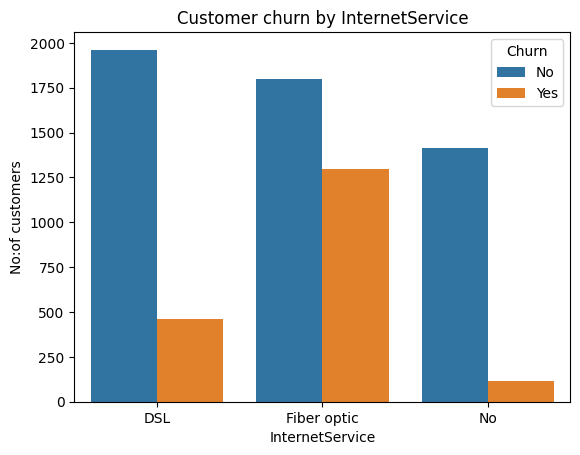

In [28]:
# Visualizing churn by Internet service
sns.countplot(x="InternetService",hue="Churn",data=df)
plt.title("Customer churn by InternetService")
plt.xlabel("InternetService")
plt.ylabel("No:of customers")
plt.show()

In [29]:
# Churn by Senior citizens
pd.crosstab(df['SeniorCitizen'],df['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


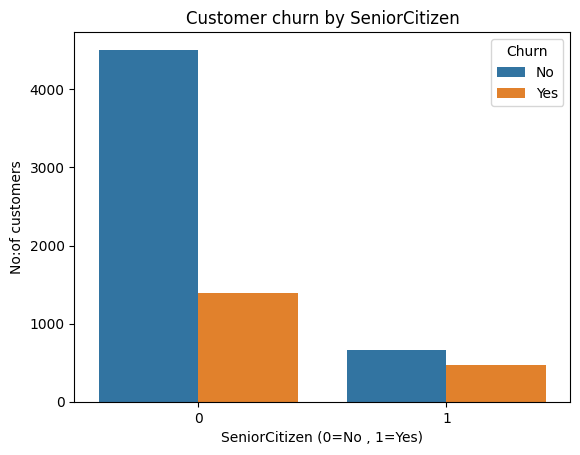

In [31]:
# Visualizing churn by Senior citizen
sns.countplot(x="SeniorCitizen",hue="Churn",data=df)
plt.title("Customer churn by SeniorCitizen")
plt.xlabel("SeniorCitizen (0=No , 1=Yes)")
plt.ylabel("No:of customers")
plt.show()

In [33]:
# analyzing Tenure
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


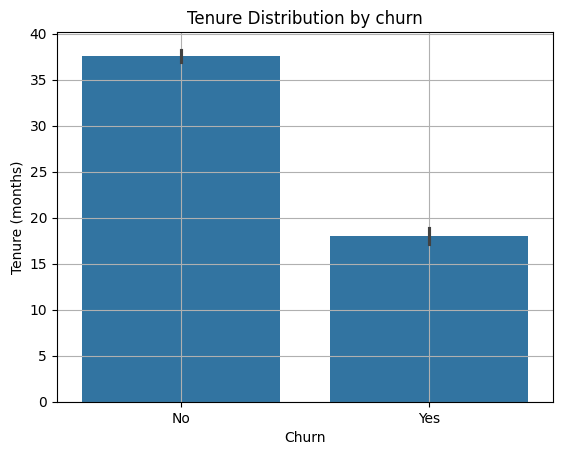

In [36]:
# Visualizing the Churn By Tenure
sns.barplot(x="Churn",y="tenure",data=df)
plt.title("Tenure Distribution by churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.grid(True)
plt.show()

In [38]:
# Analyze Monthly Charges
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


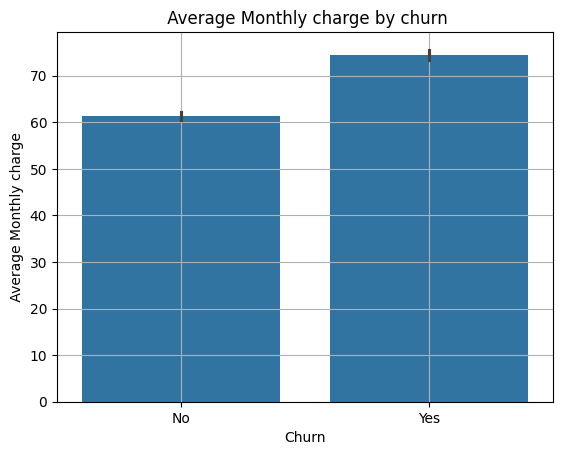

In [39]:
# visualizing churn by montly charges
sns.barplot(x="Churn",y="MonthlyCharges",data=df)
plt.title(" Average Monthly charge by churn")
plt.xlabel("Churn")
plt.ylabel(" Average Monthly charge ")
plt.grid(True)
plt.show()

In [41]:
#  Contract type + monthly charges
df.groupby(["Contract","Churn"])["MonthlyCharges"].mean()

Contract        Churn
Month-to-month  No       61.462635
                Yes      73.019396
One year        No       62.508148
                Yes      85.050904
Two year        No       60.012477
                Yes      86.777083
Name: MonthlyCharges, dtype: float64

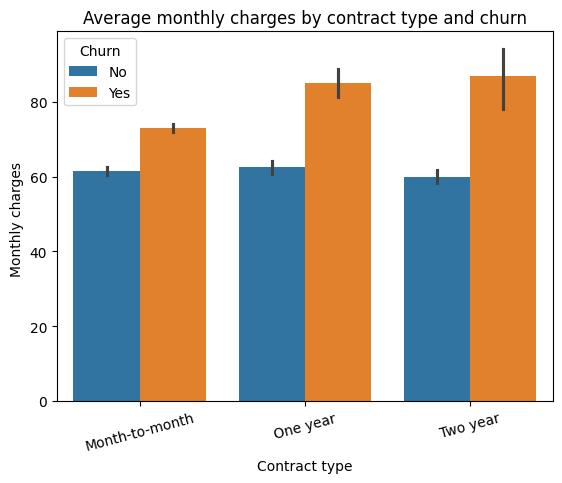

In [45]:
# viualizing contract type + monthly charges
sns.barplot(x="Contract", y="MonthlyCharges",hue="Churn", data=df)
plt.title("Average monthly charges by contract type and churn")
plt.xlabel("Contract type")
plt.ylabel("Monthly charges ")
plt.xticks(rotation = 15)
plt.show()

In [46]:
# Analyzing Churn by payment method
pd.crosstab(df['PaymentMethod'],df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


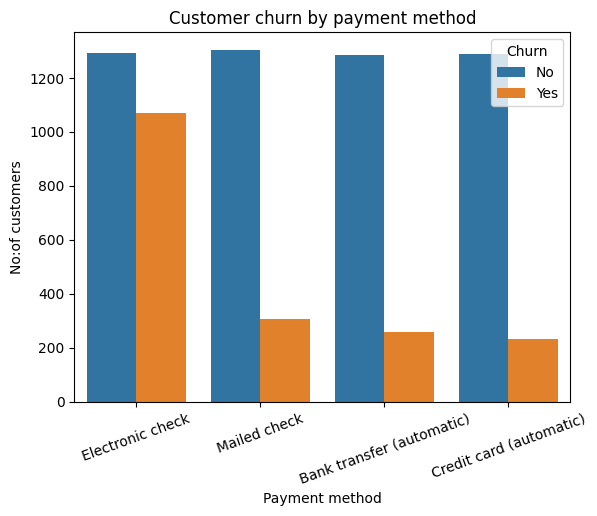

In [48]:
# visualizing payment method
sns.countplot(x="PaymentMethod",hue="Churn",data=df)
plt.title("Customer churn by payment method")
plt.xlabel("Payment method")
plt.ylabel("No:of customers")
plt.xticks(rotation = 20)
plt.show()

In [49]:
# Analyzing churn by tech support
pd.crosstab(df['TechSupport'],df['Churn'])

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


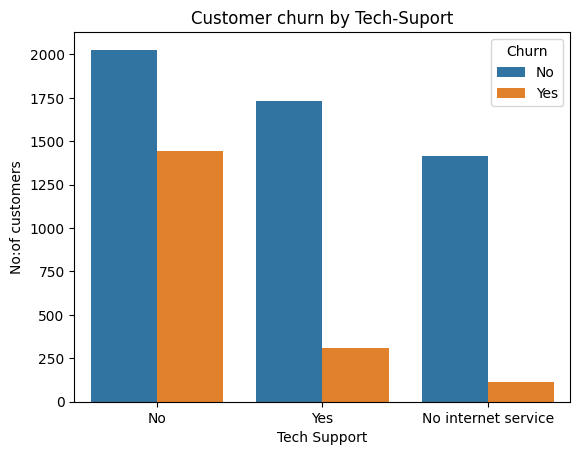

In [50]:
# visualizing by tech support

sns.countplot(x="TechSupport",hue="Churn",data=df)
plt.title("Customer churn by Tech-Suport")
plt.xlabel("Tech Support")
plt.ylabel("No:of customers")
plt.show()

In [53]:
# Analyzing tenure vs churn
df["TenureGroup"] = pd.cut(
    df['tenure'],
    bins = [0,12,24,48,72],
    labels = ["0-12","12-24",'24-48',"48-72"]
)
pd.crosstab(df['TenureGroup'],df["Churn"])

Churn,No,Yes
TenureGroup,,
0-12,1138,1037
12-24,730,294
24-48,1269,325
48-72,2026,213


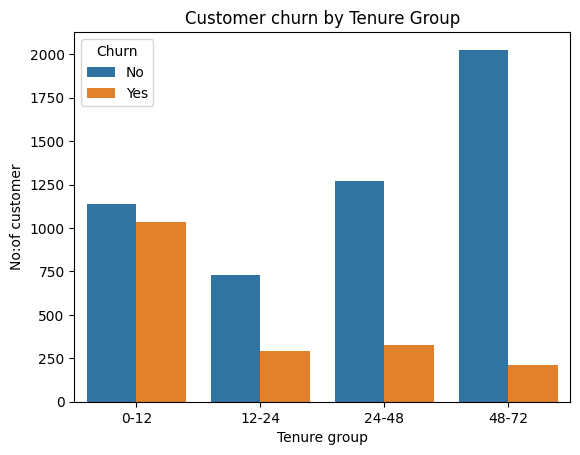

In [55]:
sns.countplot(x="TenureGroup",hue="Churn",data = df)
plt.title("Customer churn by Tenure Group")
plt.xlabel("Tenure group")
plt.ylabel("No:of customer")
plt.show()

In [56]:
# analyzing online security
pd.crosstab(df['OnlineSecurity'],df["Churn"])

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


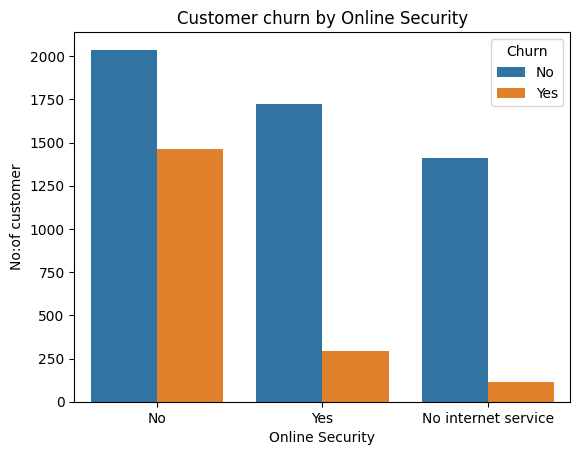

In [57]:
# visualizing churn by Online security
sns.countplot(x="OnlineSecurity",hue="Churn",data = df)
plt.title("Customer churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("No:of customer")
plt.show()


In [64]:
# Clean Total Charges column ---> It was in object so converting it into float

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors="coerce")
df['TotalCharges'].isnull().sum()


#  dropping missing values
df = df.dropna(subset=["TotalCharges"])
df.shape

#  checking the cleanned data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   object  
 1   gender            7032 non-null   object  
 2   SeniorCitizen     7032 non-null   int64   
 3   Partner           7032 non-null   object  
 4   Dependents        7032 non-null   object  
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   object  
 7   MultipleLines     7032 non-null   object  
 8   InternetService   7032 non-null   object  
 9   OnlineSecurity    7032 non-null   object  
 10  OnlineBackup      7032 non-null   object  
 11  DeviceProtection  7032 non-null   object  
 12  TechSupport       7032 non-null   object  
 13  StreamingTV       7032 non-null   object  
 14  StreamingMovies   7032 non-null   object  
 15  Contract          7032 non-null   object  
 16  PaperlessBilling  7032 non-nu

In [65]:
#  comparing total charges with churn

df.groupby("Churn")["TotalCharges"].mean()

,TotalCharges
Churn,
No,2555.344141
Yes,1531.796094


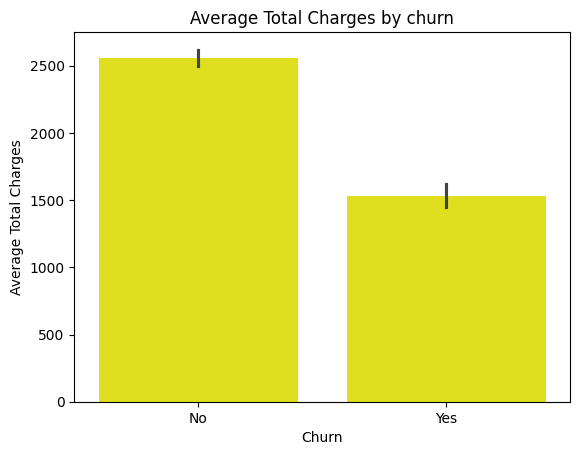

In [68]:
# Visualizing Total charge vs Churn

sns.barplot(x="Churn", y="TotalCharges",data = df,color ="yellow")
plt.title("Average Total Charges by churn")
plt.xlabel("Churn")
plt.ylabel("Average Total Charges")
plt.show()

In [71]:
# Checking the numerical relationship
corr = df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]].corr()
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


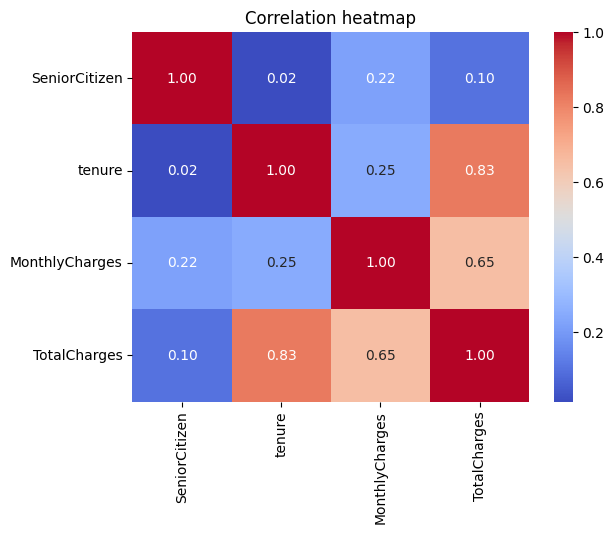

In [72]:
# Visulaizing the relationship
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation heatmap")
plt.show()